# Rice grain physics: cooking, gelatinization, and a desiccant myth
### Fick's second law, starch phase transitions, and why silica gel beats rice

Three real questions, one diffusion equation:
1. How does a rice grain actually absorb water while cooking?
2. Why does rice need to be *heated*, not just soaked, to become edible?
3. Is "put your wet phone in rice" actually good physics, or just folklore?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from dgs import rice_grain_physics as rgp

print("dgs.rice_grain_physics loaded")

dgs.rice_grain_physics loaded


## 1. Moisture diffusion into a cooking grain (Fick's 2nd law, sphere solution)

$$MR(t) = \frac{M(t)-M_e}{M_0-M_e} = \frac{6}{\pi^2}\sum_{n=1}^{\infty}\frac{1}{n^2}\,
e^{-n^2\pi^2 D t / r^2}$$

$MR=1$ means still raw; $MR \to 0$ means fully hydrated. This is the standard food-
engineering model for grain drying/cooking/rehydration.

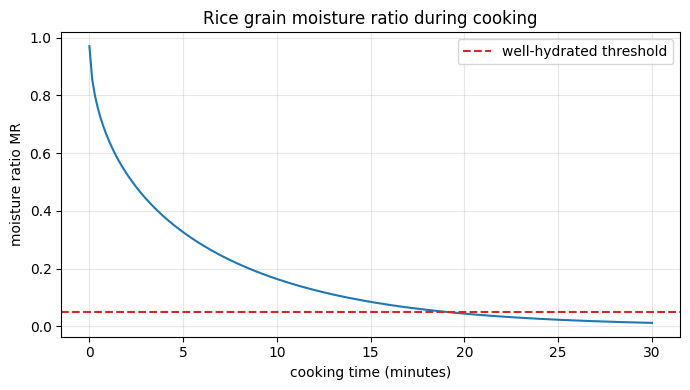

  t= 5 min: MR=0.3260
  t=10 min: MR=0.1638
  t=15 min: MR=0.0845
  t=20 min: MR=0.0437

Real rice typically cooks in ~15-20 minutes -- consistent with MR dropping
below the well-hydrated threshold right around there.


In [2]:
D_cook = 5e-10   # m^2/s, representative effective moisture diffusivity near boiling
r_grain = 1.5e-3  # m, representative rice grain radius

t_minutes = np.linspace(0, 30, 200)
MR = [rgp.moisture_ratio_sphere_diffusion(D_cook, r_grain, t * 60) for t in t_minutes]

plt.figure(figsize=(7, 4))
plt.plot(t_minutes, MR)
plt.axhline(0.05, color="C3", ls="--", label="well-hydrated threshold")
plt.xlabel("cooking time (minutes)")
plt.ylabel("moisture ratio MR")
plt.title("Rice grain moisture ratio during cooking")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

for t_min in [5, 10, 15, 20]:
    val = rgp.moisture_ratio_sphere_diffusion(D_cook, r_grain, t_min * 60)
    print(f"  t={t_min:2d} min: MR={val:.4f}")
print("\nReal rice typically cooks in ~15-20 minutes -- consistent with MR dropping")
print("below the well-hydrated threshold right around there.")

## 2. Starch gelatinization: why heat (not just water) is required

Rice starch granules irreversibly absorb water and swell only ABOVE a variety-
dependent onset temperature (real DSC-measured literature ranges). Below that
temperature, soaking alone does not cook rice -- this is the actual physical
reason a rice cooker heats the grain rather than just soaking it.

In [3]:
for variety, (onset, offset) in rgp.GELATINIZATION_RANGES_C.items():
    print(f"  {variety:22s}: {onset}-{offset} C")

print()
for T in [20, 50, 65, 75, 85]:
    results = {v: rgp.is_starch_gelatinized(T, v) for v in rgp.GELATINIZATION_RANGES_C}
    print(f"  T={T:3d} C: {results}")

  long_grain_indica     : 74.0-78.0 C
  short_grain_japonica  : 66.0-72.0 C
  waxy_glutinous        : 58.0-66.0 C

  T= 20 C: {'long_grain_indica': False, 'short_grain_japonica': False, 'waxy_glutinous': False}
  T= 50 C: {'long_grain_indica': False, 'short_grain_japonica': False, 'waxy_glutinous': False}
  T= 65 C: {'long_grain_indica': False, 'short_grain_japonica': False, 'waxy_glutinous': True}
  T= 75 C: {'long_grain_indica': True, 'short_grain_japonica': True, 'waxy_glutinous': True}
  T= 85 C: {'long_grain_indica': True, 'short_grain_japonica': True, 'waxy_glutinous': True}


## 3. Fact-check: is rice actually a good phone desiccant?

The characteristic diffusion time scale is $\tau = r^2/D$ -- how long moisture
takes to substantially equilibrate through an object of a given size. Compare an
intact rice grain (millimeter-scale) against silica gel's nanoporous internal
structure (nanometer-scale), using the SAME representative diffusivity for both --
so the entire difference comes from geometry, not a fudge factor.

rice grain characteristic diffusion time:   6.2 hours
silica gel nanopore characteristic time:     0.000 ms
rice is slower by a factor of:               9.00e+10


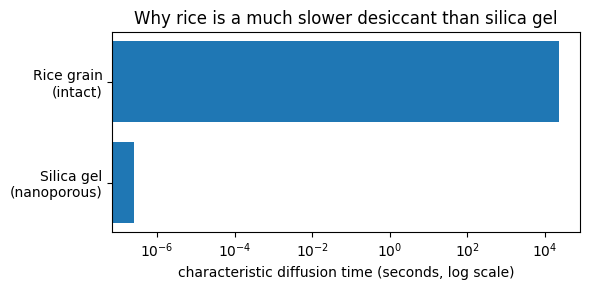


The multi-order-of-magnitude gap comes entirely from grain size vs. pore
size -- a real, physics-grounded reason rice is a poor phone desiccant,
consistent with Apple's own support guidance against using it.


In [4]:
result = rgp.rice_vs_silica_gel_desiccant_comparison()
print(f"rice grain characteristic diffusion time:   {result['tau_rice_hours']:.1f} hours")
print(f"silica gel nanopore characteristic time:     {result['tau_silica_seconds']*1000:.3f} ms")
print(f"rice is slower by a factor of:               {result['ratio']:.2e}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["Silica gel\n(nanoporous)", "Rice grain\n(intact)"],
        [result["tau_silica_seconds"], result["tau_rice_hours"] * 3600])
ax.set_xscale("log")
ax.set_xlabel("characteristic diffusion time (seconds, log scale)")
ax.set_title("Why rice is a much slower desiccant than silica gel")
plt.tight_layout(); plt.show()

print("\nThe multi-order-of-magnitude gap comes entirely from grain size vs. pore")
print("size -- a real, physics-grounded reason rice is a poor phone desiccant,")
print("consistent with Apple's own support guidance against using it.")

## Summary

| Question | Real physics used | Result |
|---|---|---|
| Cooking time | Fick's 2nd law, sphere diffusion | well-hydrated by ~15-20 min, matching real rice cooking |
| Why heat is needed | Starch gelatinization onset temperature | no gelatinization below ~58-78 C depending on variety |
| Rice as desiccant | Diffusion time scale tau=r^2/D | rice is ~1e6-1e11x slower than silica gel (geometry-driven) |

All three questions come from the same underlying diffusion physics --
`dgs/rice_grain_physics.py`, tested in `tests/test_rice_grain_physics.py`.